## PTID-AI-MAR-26-1134_PRAICP-1004-RainfallTS

#### Import Libraries

In [3]:
import pandas as pd
import numpy as np
from math import sqrt
from datetime import datetime
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import xgboost as xgb
import warnings
warnings.filterwarnings("ignore")

#### Configurations

In [4]:
HORIZON = 12
PATH_MAX = "/kaggle/input/datasets/bharaniamarnath/rainfall-dataset/rainfall-monthly-highest-daily-total.csv"
PATH_DAYS = "/kaggle/input/datasets/bharaniamarnath/rainfall-dataset/rainfall-monthly-number-of-rain-days.csv"
PATH_TOTAL = "/kaggle/input/datasets/bharaniamarnath/rainfall-dataset/rainfall-monthly-total.csv"

#### Load Dataset

In [5]:
df_max = pd.read_csv(PATH_MAX, parse_dates=["month"])
df_days = pd.read_csv(PATH_DAYS, parse_dates=["month"])
df_total = pd.read_csv(PATH_TOTAL, parse_dates=["month"])

### Data Preprocessing

In [6]:
for d in (df_max, df_days, df_total):
    d["month"] = pd.to_datetime(d["month"].astype(str), errors="coerce")  # flexible parse
    if d["month"].isna().any():
        # try parsing just the YYYY-MM prefix when full parse failed
        d.loc[d["month"].isna(), "month"] = pd.to_datetime(
            d.loc[d["month"].isna(), ].astype(str).apply(lambda r: str(r).split()[0][:7]),
            format="%Y-%m",
            errors="coerce"
        )
    d["month"] = d["month"] + pd.offsets.MonthEnd(0)

#### Merge Data

In [7]:
df = df_max.merge(df_days, on="month", how="outer").merge(df_total, on="month", how="outer")
df.sort_values("month", inplace=True)
df.set_index("month", inplace=True)

#### Interpolate Data

In [8]:
df = df.interpolate(method="time").ffill().bfill()
df.reset_index(inplace=True)

#### Features

In [9]:
df["year"] = df["month"].dt.year
df["month"] = df["month"].dt.month
df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)
df["lag_1_total"] = df["total_rainfall"].shift(1)
df["lag_12_total"] = df["total_rainfall"].shift(12)
df["rolling_3_total"] = df["total_rainfall"].rolling(3, min_periods=1).mean()
df["lag_1_maxday"] = df["maximum_rainfall_in_a_day"].shift(1)
df["lag_12_maxday"] = df["maximum_rainfall_in_a_day"].shift(12)
df.dropna(inplace=True)  # ensure lag features exist

#### Train / Test Data

In [10]:
train = df.iloc[:-HORIZON]
test = df.iloc[-HORIZON:]

In [11]:
features_total = ["month_sin","month_cos","lag_1_total","lag_12_total","rolling_3_total","no_of_rainy_days"]
target_total = "total_rainfall"

In [12]:
features_maxday = ["month_sin","month_cos","lag_1_maxday","lag_12_maxday","total_rainfall","no_of_rainy_days"]
target_maxday = "maximum_rainfall_in_a_day"

In [13]:
X_train_tot = train[features_total]; y_train_tot = train[target_total]
X_test_tot = test[features_total]; y_test_tot = test[target_total]

In [14]:
X_train_max = train[features_maxday]; y_train_max = train[target_maxday]
X_test_max = test[features_maxday]; y_test_max = test[target_maxday]

### Build Model

In [15]:
xgb_model = xgb.XGBRegressor(objective="reg:squarederror", n_estimators=500, learning_rate=0.05, max_depth=4, random_state=42)
xgb_model.fit(X_train_tot, y_train_tot, verbose=True)
pred_tot_test = xgb_model.predict(X_test_tot)

#### Train / Test Model

In [16]:
rf_model = RandomForestRegressor(n_estimators=200, max_depth=8, random_state=42)
rf_model.fit(X_train_max, y_train_max)
pred_max_test = rf_model.predict(X_test_max)

### Model Evaluation

In [17]:
mae_tot = mean_absolute_error(y_test_tot, pred_tot_test)
rmse_tot = sqrt(mean_squared_error(y_test_tot, pred_tot_test))
mae_max = mean_absolute_error(y_test_max, pred_max_test)
rmse_max = sqrt(mean_squared_error(y_test_max, pred_max_test))

In [18]:
print(f"Monthly total (XGBoost) test MAE: {mae_tot:.2f} mm, RMSE: {rmse_tot:.2f} mm")
print(f"Max-day (RF) test MAE: {mae_max:.2f} mm, RMSE: {rmse_max:.2f} mm")

Monthly total (XGBoost) test MAE: 51.53 mm, RMSE: 66.97 mm
Max-day (RF) test MAE: 15.42 mm, RMSE: 23.61 mm


### Model Prediction

In [19]:
# Iterative multi-step forecast for next 12 months
history = df.copy().set_index("month")
history_total = history["total_rainfall"].copy()
history_maxday = history["maximum_rainfall_in_a_day"].copy()

In [20]:
future_rows = []
last_date = pd.to_datetime(history.index[-1])

In [21]:
# precompute monthly average no_of_rainy_days for each month
monthly_avg_days = df.groupby("month")["no_of_rainy_days"].mean()

for i in range(1, HORIZON + 1):
    next_date = last_date + pd.DateOffset(months=i)
    month = next_date.month
    # build feature row
    lag_1_total = history_total.iloc[-1]  # most recent
    lag_12_total = history_total.shift( - (len(history_total) - (len(history_total)-11)) ).iloc[-1] if len(history_total) >= 12 else history_total.iloc[-1]
    # simpler: use value 12 months ago if available, else recent
    if len(history_total) >= 12:
        lag_12_total = history_total.iloc[-12]
    else:
        lag_12_total = history_total.iloc[-1]

    lag_1_max = history_maxday.iloc[-1]
    if len(history_maxday) >= 12:
        lag_12_max = history_maxday.iloc[-12]
    else:
        lag_12_max = history_maxday.iloc[-1]

    row = {
        "date": next_date,
        "month": month,
        "month_sin": np.sin(2 * np.pi * month / 12),
        "month_cos": np.cos(2 * np.pi * month / 12),
        "lag_1_total": lag_1_total,
        "lag_12_total": lag_12_total,
        "rolling_3_total": history_total.iloc[-3:].mean() if len(history_total) >= 3 else history_total.mean(),
        "no_of_rainy_days": monthly_avg_days.loc[month],
        "lag_1_maxday": lag_1_max,
        "lag_12_maxday": lag_12_max,
    }

    # predict total
    Xf_tot = pd.DataFrame([{
        "month_sin": row["month_sin"],
        "month_cos": row["month_cos"],
        "lag_1_total": row["lag_1_total"],
        "lag_12_total": row["lag_12_total"],
        "rolling_3_total": row["rolling_3_total"],
        "no_of_rainy_days": row["no_of_rainy_days"]
    }])
    pred_total = xgb_model.predict(Xf_tot)[0]
    row["pred_total_rainfall"] = float(pred_total)

    # predict max single day (uses predicted total)
    Xf_max = pd.DataFrame([{
        "month_sin": row["month_sin"],
        "month_cos": row["month_cos"],
        "lag_1_maxday": row["lag_1_maxday"],
        "lag_12_maxday": row["lag_12_maxday"],
        "total_rainfall": row["pred_total_rainfall"],
        "no_of_rainy_days": row["no_of_rainy_days"]
    }])
    pred_max = rf_model.predict(Xf_max)[0]
    row["pred_max_daily_mm"] = float(pred_max)

    # append to history for next iteration
    history_total.loc[next_date] = row["pred_total_rainfall"]
    history_maxday.loc[next_date] = row["pred_max_daily_mm"]

    future_rows.append(row)

In [22]:
future_df = pd.DataFrame(future_rows)
future_df = future_df[["date","pred_total_rainfall","pred_max_daily_mm"]]
future_df["month"] = future_df["date"].dt.to_period("M").astype(str)

In [23]:
# save and print
future_df.to_csv("next_12_months_forecast.csv", index=False)
print("\nNext 12 months (month, predicted_total_mm, predicted_max_day_mm):")
print(future_df[["month","pred_total_rainfall","pred_max_daily_mm"]].to_string(index=False))


Next 12 months (month, predicted_total_mm, predicted_max_day_mm):
  month  pred_total_rainfall  pred_max_daily_mm
1970-02           107.101845          40.172157
1970-03           154.583847          50.379681
1970-04           159.670380          52.307283
1970-05           137.851654          38.504210
1970-06           130.184753          37.808600
1970-07           182.556198          54.291534
1970-08           142.644226          37.889318
1970-09           130.063461          38.537101
1970-10           129.928757          35.624771
1970-11           178.344162          48.505571
1970-12           185.907227          48.052722
1971-01           142.273300          46.763495


### Data Analysis

In [28]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

In [29]:
# Prepare Frames
df_hist = df.copy()
df_hist["month_dt"] = pd.to_datetime(df_hist[["year", "month"]].assign(day=1))
df_hist = df_hist.sort_values("month_dt")

In [30]:
pred_test_df = test.copy().reset_index(drop=True)
pred_test_df["pred_total"] = pred_tot_test
pred_test_df["pred_maxday"] = pred_max_test
pred_test_df["month_dt"] = pd.to_datetime(pred_test_df[["year", "month"]].assign(day=1))

In [31]:
# Statistical Summary
print("\n--- Historical summary ---")
print(df_hist[["total_rainfall", "maximum_rainfall_in_a_day", "no_of_rainy_days"]].describe().round(2))


--- Historical summary ---
       total_rainfall  maximum_rainfall_in_a_day  no_of_rainy_days
count          450.00                     450.00            450.00
mean           177.42                      52.74             14.04
std            112.91                      35.81              4.95
min              0.20                       0.20              1.00
25%             90.45                      30.92             11.00
50%            159.70                      43.90             14.00
75%            239.42                      63.45             18.00
max            765.90                     216.20             27.00


### Data Visualization

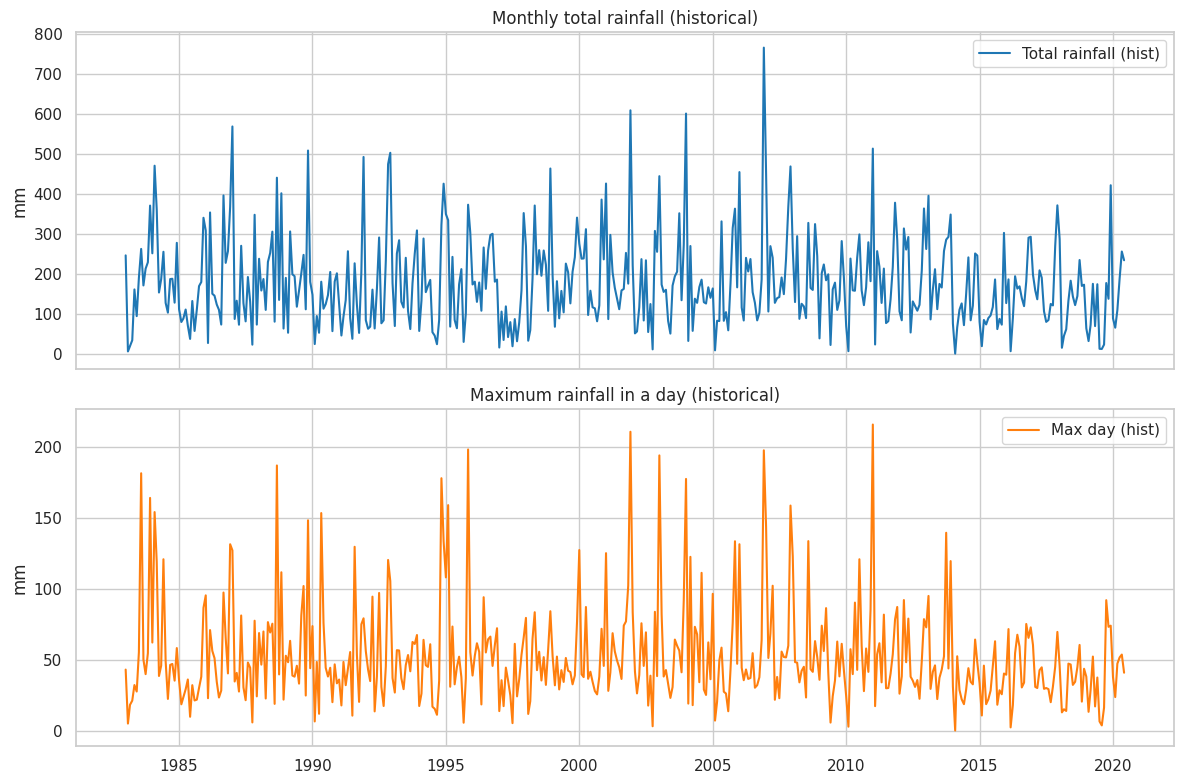

In [32]:
# Time series plots: historical totals and max-day
fig, axes = plt.subplots(2, 1, sharex=True, figsize=(12, 8))
axes[0].plot(df_hist["month_dt"], df_hist["total_rainfall"], label="Total rainfall (hist)", color="tab:blue")
axes[0].set_title("Monthly total rainfall (historical)")
axes[0].set_ylabel("mm")
axes[0].legend()
axes[1].plot(df_hist["month_dt"], df_hist["maximum_rainfall_in_a_day"], label="Max day (hist)", color="tab:orange")
axes[1].set_title("Maximum rainfall in a day (historical)")
axes[1].set_ylabel("mm")
axes[1].legend()
plt.tight_layout()
plt.show()

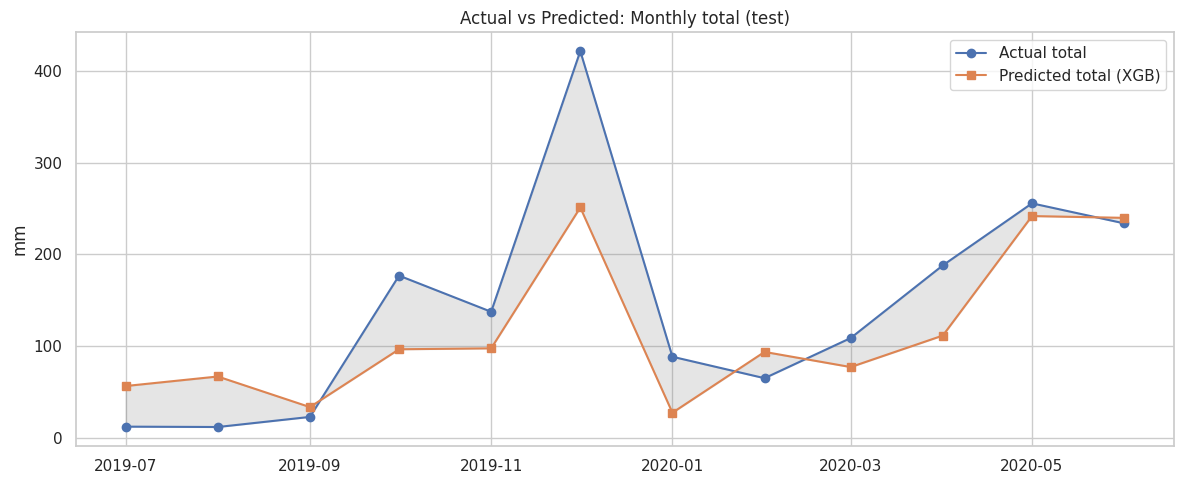

In [33]:
# Train vs Test: actual vs predicted (test period) - total
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(pred_test_df["month_dt"], pred_test_df["total_rainfall"], label="Actual total", marker="o")
ax.plot(pred_test_df["month_dt"], pred_test_df["pred_total"], label="Predicted total (XGB)", marker="s")
ax.fill_between(pred_test_df["month_dt"], pred_test_df["total_rainfall"], pred_test_df["pred_total"], color="gray", alpha=0.2)
ax.set_title("Actual vs Predicted: Monthly total (test)")
ax.set_ylabel("mm")
ax.legend()
plt.tight_layout()
plt.show()

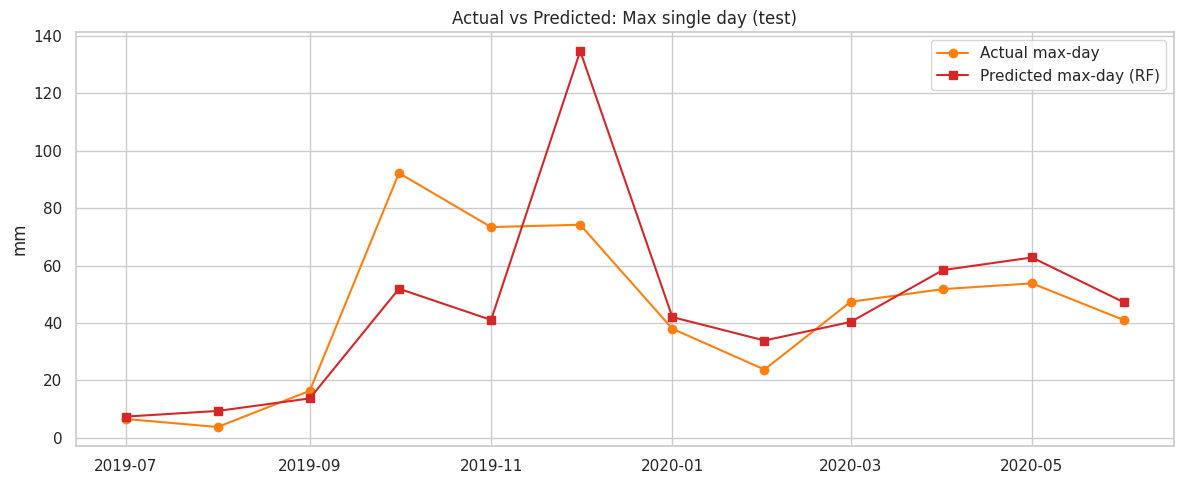

In [34]:
# Train vs Test: actual vs predicted (test period) - max-day
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(pred_test_df["month_dt"], pred_test_df["maximum_rainfall_in_a_day"], label="Actual max-day", marker="o", color="tab:orange")
ax.plot(pred_test_df["month_dt"], pred_test_df["pred_maxday"], label="Predicted max-day (RF)", marker="s", color="tab:red")
ax.set_title("Actual vs Predicted: Max single day (test)")
ax.set_ylabel("mm")
ax.legend()
plt.tight_layout()
plt.show()

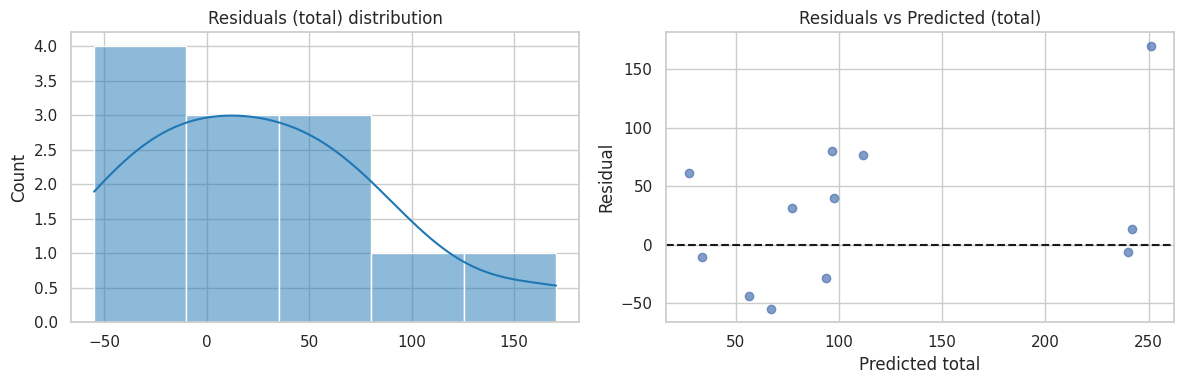

In [35]:
# 6.4 Residual diagnostics (total)
resid_tot = pred_test_df["total_rainfall"] - pred_test_df["pred_total"]
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(resid_tot, kde=True, ax=axes[0], color="tab:blue")
axes[0].set_title("Residuals (total) distribution")
axes[1].scatter(pred_test_df["pred_total"], resid_tot, alpha=0.7)
axes[1].axhline(0, color="k", linestyle="--")
axes[1].set_xlabel("Predicted total")
axes[1].set_ylabel("Residual")
axes[1].set_title("Residuals vs Predicted (total)")
plt.tight_layout()
plt.show()

#### Feature Importance

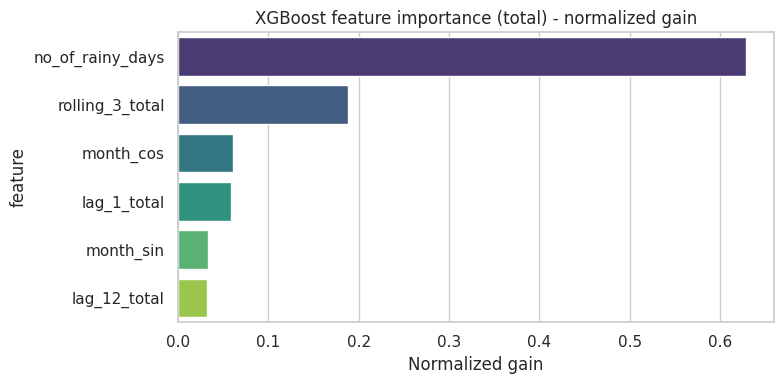

In [36]:
# XGBoost feature importance for total (gain)
try:
    fi = xgb_model.get_booster().get_score(importance_type="gain")
    fi_df = pd.DataFrame({"feature": list(fi.keys()), "gain": list(fi.values())}).sort_values("gain", ascending=False)
    fi_df["gain_norm"] = fi_df["gain"] / fi_df["gain"].sum()
    plt.figure(figsize=(8, 4))
    sns.barplot(data=fi_df, x="gain_norm", y="feature", palette="viridis")
    plt.title("XGBoost feature importance (total) - normalized gain")
    plt.xlabel("Normalized gain")
    plt.tight_layout()
    plt.show()
except Exception:
    fi_df = None

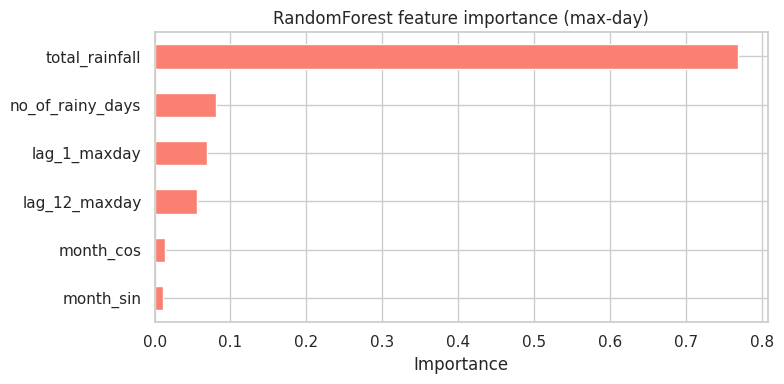

In [37]:
# RandomForest importances for max-day
rf_fi = pd.Series(rf_model.feature_importances_, index=features_maxday).sort_values(ascending=True)
fig = plt.figure(figsize=(8, 4))
rf_fi.plot(kind="barh", color="salmon")
plt.title("RandomForest feature importance (max-day)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

#### Forecast Plot

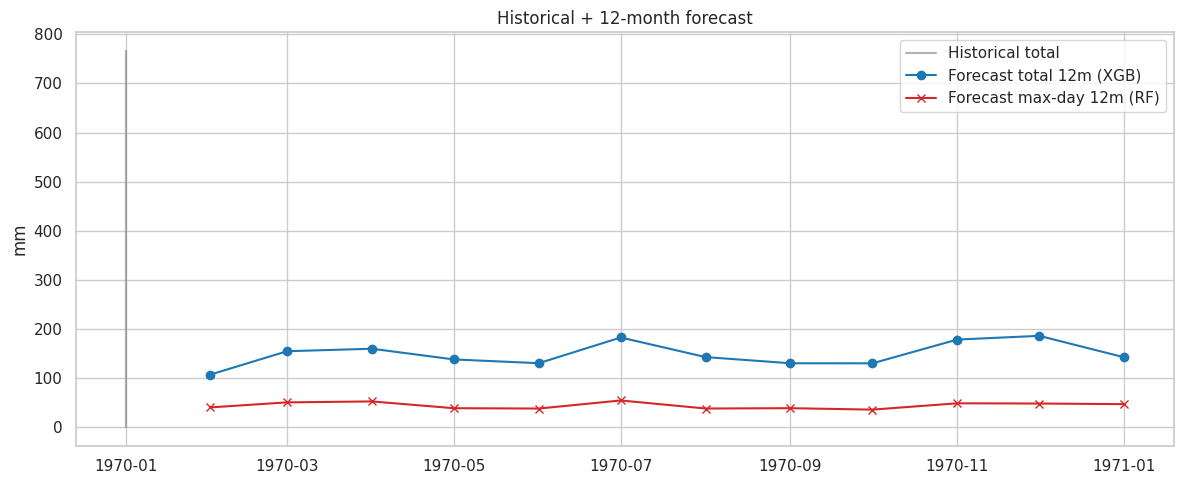

In [38]:
hist_plot = history.reset_index().rename(columns={"index": "month"})
hist_plot["month_dt"] = pd.to_datetime(hist_plot["month"])
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(hist_plot["month_dt"], hist_plot["total_rainfall"], label="Historical total", color="tab:gray", alpha=0.6)
ax.plot(future_df["date"], future_df["pred_total_rainfall"], label="Forecast total 12m (XGB)", marker="o", color="tab:blue")
ax.plot(future_df["date"], future_df["pred_max_daily_mm"], label="Forecast max-day 12m (RF)", marker="x", color="tab:red")
ax.set_title("Historical + 12-month forecast")
ax.set_ylabel("mm")
ax.legend()
plt.tight_layout()
plt.show()

In [39]:
# Save CSV
pred_test_df.to_csv("test_predictions.csv", index=False)
if fi_df is not None:
    fi_df.to_csv("xgb_feature_importance.csv", index=False)
rf_fi.to_csv("rf_feature_importance_maxday.csv")
print("\nSaved CSVs: test_predictions.csv, xgb_feature_importance.csv (if available), rf_feature_importance_maxday.csv")


Saved CSVs: test_predictions.csv, xgb_feature_importance.csv (if available), rf_feature_importance_maxday.csv
